In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

sns.set_style('whitegrid')

In [2]:
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
!ls csv

0e9cd673-8e06-4810-b370-8b9930ee312a.csv
2021-09-22.csv
2021-09-23.csv
2021-10-01.csv
2021-10-05.csv
2021-10-07.csv
2021-10-28-cleaned.csv
2021-10-28.csv
2021-11-05.csv
50c39121-3de2-4b6b-b134-bb51732c1d6f.csv
a3d86f3b-eb45-4641-b05d-30dff7423e6b.csv
df_score.csv
res.csv
viewer_lat_long_centroids.csv


In [4]:
data = pd.read_csv("csv/2021-11-05.csv", index_col = False)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21446377 entries, 0 to 21446376
Data columns (total 21 columns):
viewer_id                        object
broadcaster_id                   object
viewer_age                       float64
viewer_gender                    object
viewer_longitude                 float64
viewer_latitude                  float64
viewer_lang                      object
viewer_country                   object
broadcaster_age                  float64
broadcaster_gender               object
broadcaster_longitude            float64
broadcaster_latitude             float64
broadcaster_lang                 object
broadcaster_country              object
duration                         float64
viewer_network                   object
broadcaster_network              object
count                            int64
broadcast_active_viewer_count    object
viewer_lat_long_cluster          int64
rank                             int64
dtypes: float64(7), int64(3), object(11)


In [6]:
data['broadcaster_id'].nunique()

138139

In [7]:
data.describe()

,viewer_age,viewer_longitude,viewer_latitude,broadcaster_age,broadcaster_longitude,broadcaster_latitude,duration,count,viewer_lat_long_cluster,rank
count,2.144638e+07,2.144638e+07,2.144638e+07,2.144638e+07,2.144638e+07,2.144638e+07,2.132286e+07,2.144638e+07,2.144638e+07,21446377.0
mean,3.476892e+01,-3.841670e+01,3.118665e+01,3.117435e+01,-4.828111e+01,3.184315e+01,5.182158e+02,2.754313e+00,2.038938e+00,1.0
std,1.013043e+01,7.832797e+01,1.957667e+01,8.271227e+00,7.718859e+01,1.737381e+01,1.586815e+04,9.701030e+01,2.332563e+00,0.0
min,1.800000e+01,-1.781194e+02,-8.124200e+01,1.800000e+01,-1.781194e+02,-5.486670e+01,1.000000e+00,1.000000e+00,0.000000e+00,1.0
25%,2.700000e+01,-9.000000e+01,2.701670e+01,2.500000e+01,-9.470100e+01,2.900000e+01,5.000000e+00,1.000000e+00,0.000000e+00,1.0
50%,3.300000e+01,-7.630000e+01,3.610000e+01,3.000000e+01,-7.920500e+01,3.520000e+01,1.400000e+01,1.000000e+00,2.000000e+00,1.0
75%,4.000000e+01,8.772000e-01,4.199580e+01,3.500000e+01,-3.361000e+00,4.173160e+01,6.000000e+01,1.000000e+00,3.000000e+00,1.0
max,2.000000e+02,1.807650e+02,7.946600e+01,1.240000e+02,1.801962e+02,7.570000e+01,2.212804e+07,2.246760e+05,7.000000e+00,1.0


### Preprocessing data

In [8]:
df = data.copy()

In [9]:
df.drop(labels=['rank'], axis=1, inplace=True)

In [10]:
df.dropna(inplace=True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 19204879 entries, 0 to 21446375
Data columns (total 20 columns):
viewer_id                        object
broadcaster_id                   object
viewer_age                       float64
viewer_gender                    object
viewer_longitude                 float64
viewer_latitude                  float64
viewer_lang                      object
viewer_country                   object
broadcaster_age                  float64
broadcaster_gender               object
broadcaster_longitude            float64
broadcaster_latitude             float64
broadcaster_lang                 object
broadcaster_country              object
duration                         float64
viewer_network                   object
broadcaster_network              object
count                            int64
broadcast_active_viewer_count    object
viewer_lat_long_cluster          int64
dtypes: float64(7), int64(2), object(11)
memory usage: 3.0+ GB


drop data from 21M to 19M

#### generate age bucket

In [12]:
def age_bucket(age):
    # min(age) = 18
    if age < 25:
        return 0
    elif age < 30:
        return 1
    elif age < 35:
        return 2
    elif age < 40:
        return 3
    elif age < 45:
        return 4
    elif age < 50:
        return 5
    elif age < 55:
        return 6
    elif age < 60:
        return 7
    elif age < 65:
        return 8
    else:
        return 9

In [13]:
df['viewer_age_bucket'] = df['viewer_age'].apply(lambda x: age_bucket(x))

<AxesSubplot:title={'center':'The density plot of viewer_age_bucket'}, ylabel='Frequency'>

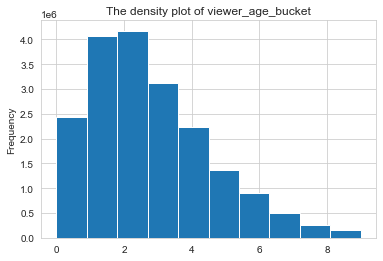

In [14]:
df['viewer_age_bucket'].plot(kind="hist", title="The density plot of viewer_age_bucket", bins=10)

### Cutoff = 12

In [14]:
cutoff = 12

In [15]:
df['y'] = df['duration'].apply(lambda x: 1 if x > cutoff else 0)

In [16]:
FEATURES = [
	'broadcaster_id',
	'viewer_network',
	'viewer_age_bucket',
	'viewer_gender',
	'viewer_lang',
	'viewer_country',
	'viewer_lat_long_cluster'
]

In [17]:
df_pos = (df[df['y'] == 1].groupby(FEATURES)
          .agg({'viewer_id': np.size})
          .reset_index()
          .rename(columns={'viewer_id': 'weight'}))

In [18]:
df_pos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2986618 entries, 0 to 2986617
Data columns (total 8 columns):
broadcaster_id             object
viewer_network             object
viewer_age_bucket          int64
viewer_gender              object
viewer_lang                object
viewer_country             object
viewer_lat_long_cluster    int64
weight                     int64
dtypes: int64(3), object(5)
memory usage: 182.3+ MB


In [19]:
df_neg = (df[df['y'] == 0].groupby(FEATURES)
          .agg({'viewer_id': np.size})
          .reset_index()
          .rename(columns={'viewer_id': 'weight'}))

In [20]:
df_neg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3029833 entries, 0 to 3029832
Data columns (total 8 columns):
broadcaster_id             object
viewer_network             object
viewer_age_bucket          int64
viewer_gender              object
viewer_lang                object
viewer_country             object
viewer_lat_long_cluster    int64
weight                     int64
dtypes: int64(3), object(5)
memory usage: 184.9+ MB


In [21]:
df_pos['y'] = 1

In [22]:
df_neg['y'] = 0

In [23]:
df_agg = pd.concat([df_pos, df_neg], ignore_index=True)

In [24]:
df_agg.head()

,broadcaster_id,viewer_network,viewer_age_bucket,viewer_gender,viewer_lang,viewer_country,viewer_lat_long_cluster,weight,y
0,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,0,male,en,US,0,2,1
1,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,1,male,en,US,0,4,1
2,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,female,es,US,0,1,1
3,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,male,en,US,0,2,1
4,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,3,male,en,US,0,4,1


#### Lightgbm Model

In [25]:
from typing import Dict, Iterable, Tuple
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import log_loss, roc_auc_score, plot_confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [26]:
def split(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """return distinct train and test sets"""
    return train_test_split(df, random_state=0, test_size=0.3)

In [27]:
def decompose(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """break down data into features, labels and weights"""
    return df.drop(['y', 'w'], axis=1), df.y, df.w

In [28]:
def ungroup(X: pd.DataFrame, w: pd.DataFrame) -> pd.DataFrame:
    """expand all repeated columns"""
    return X.reindex(X.index.repeat(w))

In [29]:
def group(X: pd.DataFrame) -> pd.DataFrame:
    """append weight to pandas dataframe by groupby all columns"""
    return X.groupby(list(X.columns)).size().to_frame('w').reset_index()

In [30]:
def get_feature_mappings(X: pd.DataFrame) -> Dict[str, Dict[str, int]]:
    """map of value to pandas category"""
    return {
        f: {str(x): i
            for i, x in enumerate(X[f].cat.categories, start=1)}
        for f in X
    }

In [31]:
def etl(X: pd.DataFrame,
        y: pd.Series,
        w: pd.Series = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """transform the data"""
    X = X.assign(y=y)
    if w is not None:
        X_train, X_test = split(ungroup(X, w))
        return group(X_train), group(X_test)
    else:
        X['w'] = 1
        return split(X)

In [32]:
def predict(model: lgb.Booster,
            X: pd.DataFrame,
            regression: bool = False) -> pd.Series:
    """prediction wrapper"""
    return model.predict(X) if regression else model.predict_proba(X)[:, 1]

In [33]:
def evaluate(X: pd.DataFrame,
             y: pd.Series,
             w: pd.Series,
             y_pred: pd.Series,
             regression: bool = False) -> Dict[str, any]:
    """calculate evaluation metrics"""
    metrics = {'records': str(len(y)), 'weights': str(sum(w))}
#     metrics['raw_accuracy'] = prediction_metrics(y, y_pred, weights=w)
    if not regression:
        metrics['log_loss'] = log_loss(y, y_pred, sample_weight=w)
        metrics['roc_auc_score'] = roc_auc_score(y, y_pred, sample_weight=w)
    return metrics

In [34]:
def build_model(
    X: pd.DataFrame,
    y: pd.Series,
    w: pd.Series = None,
    categories: Iterable[str] = [],
    unencoded_categories: Iterable[str] = [],
    params: Dict[str, any] = {},
    regression: bool = False
) -> Tuple[lgb.LGBMModel, Dict[str, any], pd.DataFrame, pd.DataFrame]:
    """take the sql data and output model and metadata"""
    X[unencoded_categories] = X[unencoded_categories].astype('category')
    metadata = {
        'model_type': 'lightgbm',
        'features': list(X),
        'category_features': categories,
        'mappings': get_feature_mappings(X[unencoded_categories]),
    }

    train_df, test_df = etl(X, y, w)
    X, y, w = decompose(train_df)
    
    model = (lgb.LGBMRegressor if regression else lgb.LGBMClassifier)(random_state=0, **params)
    model.fit(X, y, w, categorical_feature=categories)
    train_df['y_pred'] = predict(model, X, regression)
    
    metadata['train_accuracy'] = evaluate(X, y, w, train_df['y_pred'], regression)
    metadata['train_accuracy']['data_type'] = 'train'
    
    X, y, w = decompose(test_df)
    test_df['y_pred'] = predict(model, X, regression)
    metadata['test_accuracy'] = evaluate(X, y, w, test_df['y_pred'], regression)
    metadata['test_accuracy']['data_type'] = 'test'
    return model, metadata, train_df, test_df

In [35]:
df_agg.head()

,broadcaster_id,viewer_network,viewer_age_bucket,viewer_gender,viewer_lang,viewer_country,viewer_lat_long_cluster,weight,y
0,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,0,male,en,US,0,2,1
1,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,1,male,en,US,0,4,1
2,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,female,es,US,0,1,1
3,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,male,en,US,0,2,1
4,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,3,male,en,US,0,4,1


In [36]:
pred_model, pred_metadata, train_df, test_df = build_model(
    X=df_agg[FEATURES],
    y=df_agg['y'],
    w=df_agg['weight'],
    categories=FEATURES,
    unencoded_categories=FEATURES,
    params={'n_estimators': 300, 'num_leaves': 300, "learning_rate": 0.1, 'max_bin': 100},
    regression=False
)

/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/pandas/core/frame.py:3509: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]
/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/lightgbm/basic.py:1551: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


In [37]:
pred_metadata['train_accuracy']

{'records': '4805003',
 'weights': '13443415',
 'log_loss': 0.6507499715160181,
 'roc_auc_score': 0.654030164974317,
 'data_type': 'train'}

In [38]:
pred_metadata['test_accuracy']

{'records': '2733383',
 'weights': '5761464',
 'log_loss': 0.6684211996584515,
 'roc_auc_score': 0.6161787882631973,
 'data_type': 'test'}

In [39]:
train_df.head()

,broadcaster_id,viewer_network,viewer_age_bucket,viewer_gender,viewer_lang,viewer_country,viewer_lat_long_cluster,y,w,y_pred
0,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,0,male,en,US,0,1,1,0.553956
1,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,1,male,en,US,0,0,1,0.566678
2,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,1,male,en,US,0,1,4,0.566678
3,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,male,en,US,0,0,1,0.591293
4,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,3,male,en,US,0,0,4,0.596002


In [40]:
train_df['y_pred_binned'] = pd.qcut(train_df['y_pred'], q=10)

In [41]:
train_df.head()

,broadcaster_id,viewer_network,viewer_age_bucket,viewer_gender,viewer_lang,viewer_country,viewer_lat_long_cluster,y,w,y_pred,y_pred_binned
0,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,0,male,en,US,0,1,1,0.553956,"(0.533, 0.556]"
1,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,1,male,en,US,0,0,1,0.566678,"(0.556, 0.59]"
2,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,1,male,en,US,0,1,4,0.566678,"(0.556, 0.59]"
3,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,male,en,US,0,0,1,0.591293,"(0.59, 0.628]"
4,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,3,male,en,US,0,0,4,0.596002,"(0.59, 0.628]"


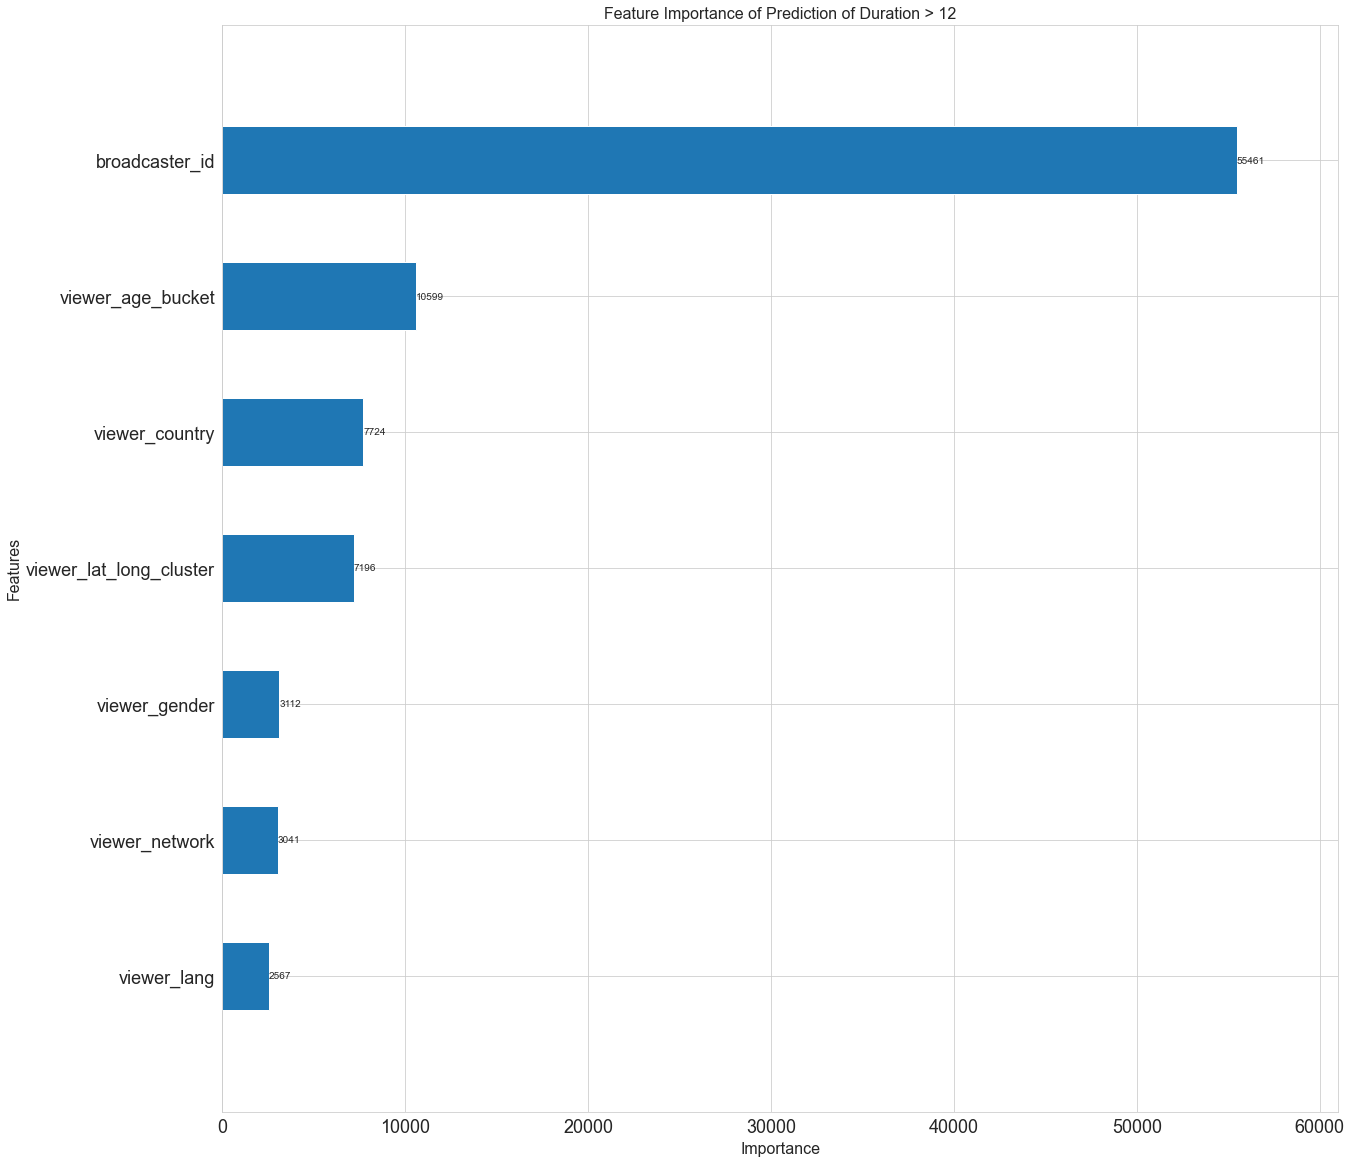

In [42]:
lgb.plot_importance(pred_model, figsize=(20,20), height=0.5)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title("Feature Importance of Prediction of Duration > 12", fontsize=16)
plt.xlabel("Importance", fontsize=16)
plt.ylabel("Features", fontsize=16)
plt.show()

In [43]:
boost = pred_model.booster_

In [44]:
imps = pd.DataFrame({'feature': boost.feature_name(),
                    'importance': boost.feature_importance()})

In [45]:
imps.sort_values('importance',ascending=False)

,feature,importance
0,broadcaster_id,55461
2,viewer_age_bucket,10599
5,viewer_country,7724
6,viewer_lat_long_cluster,7196
3,viewer_gender,3112
1,viewer_network,3041
4,viewer_lang,2567


In [46]:
test_df

,broadcaster_id,viewer_network,viewer_age_bucket,viewer_gender,viewer_lang,viewer_country,viewer_lat_long_cluster,y,w,y_pred
0,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,0,male,en,US,0,1,1,0.553956
1,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,female,es,US,0,1,1,0.648012
2,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,male,en,US,0,0,1,0.591293
3,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,male,en,US,0,1,2,0.591293
4,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,3,male,en,US,0,1,1,0.596002
...,...,...,...,...,...,...,...,...,...,...
2733378,ff fe 50 07 3c 23 30 26 29 bb b2 bd 64 6a 0e ac,pof,2,female,en,US,0,0,2,0.585053
2733379,ff fe 50 07 3c 23 30 26 29 bb b2 bd 64 6a 0e ac,pof,3,male,en,US,0,0,1,0.467424
2733380,ff fe 50 07 3c 23 30 26 29 bb b2 bd 64 6a 0e ac,pof,4,female,en,US,0,1,1,0.589966
2733381,ff fe 50 07 3c 23 30 26 29 bb b2 bd 64 6a 0e ac,skout,0,female,en,US,0,1,1,0.484422


In [47]:
test_df['y_pred_class'] = test_df['y_pred'].apply(lambda x: 1 if x >= 0.5 else 0)

In [48]:
print(classification_report(test_df['y'], test_df['y_pred_class']))

              precision    recall  f1-score   support

           0       0.58      0.42      0.48   1343732
           1       0.56      0.71      0.62   1389651

    accuracy                           0.56   2733383
   macro avg       0.57      0.56      0.55   2733383
weighted avg       0.57      0.56      0.55   2733383



Plotting 54th tree...


dot: graph is too large for cairo-renderer bitmaps. Scaling by 0.0766324 to fit


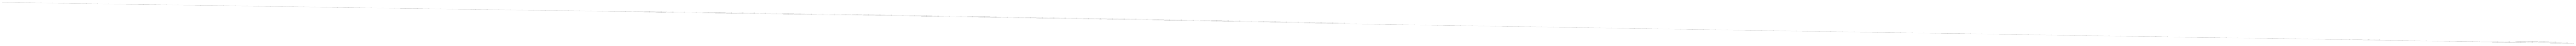

In [49]:
print('Plotting 54th tree...')  # one tree use categorical feature to split
ax = lgb.plot_tree(boost, tree_index=53, figsize=(20, 20), show_info=['split_gain'])
fig = plt.gcf()
fig.set_size_inches(150, 100)
fig.savefig('tree.png')

In [105]:
import traceback
import os
import shutil
import json
import zipfile
from datetime import datetime

In [86]:
def safe_delete_folder(path):
    if os.path.exists(path):
        shutil.rmtree(path)

In [87]:
def init_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [88]:
class SavingModelException(RuntimeError):
    pass

In [89]:
def serialize_model_params(model_params: dict, file_path: str, format_: str="json"):
    if format_ == "edn":
        with open(file_path, "w", encoding='utf8') as text_file:
            text_file.write(edn.dumps(model_params))
    elif format_ == "pickle":
        with open(file_path, "wb") as obj_file:
            pickle.dump(model_params, obj_file, protocol=pickle.HIGHEST_PROTOCOL)
    elif format_ == "json":
        with open(file_path, "w") as obj_file:
            json.dump(model_params, obj_file)
    else:
        raise SavingModelException("model serialization data format {} not supported".format(format_))


def deserialize_model_params(file_path: str, format_: str="json"):
    if format_ == "edn":
        with open(file_path, 'r', encoding="utf-8") as text_file:
            return dict(edn.loads(text_file.read()))
    elif format_ == "pickle":
        with open(file_path, 'rb') as obj_file:
            return pickle.load(obj_file)
    elif format_ == "json":
        with open(file_path, "r") as obj_file:
            return json.load(obj_file)
    else:
        raise SavingModelException("model deserialization data format {} not supported".format(format_))

In [106]:
def save_to_local_zip_file(model_name, model, params):
    ''' Save three files into local folder and zip the folder as a zipped file
        read_me.json tells predict model name, type, and model file, and hyper-params file
        model_xxx.txt is the lightgbm model
        optimus_hyper_params_xxx.json includes all parameters
     '''
    try:
        # Step 1: clean the previous folder if existing
        local_folder = f"./local_{model_name}"
        local_zip_model_path = f"./local_{model_name}.zip"
        safe_delete_folder(local_folder)
        init_folder(local_folder)

        # Step 2: save model and hyper parameters into target zip file
        local_model_path = f"{local_folder}/ranking_model_{model_name}.txt"
        model.save_model(local_model_path)

        local_feature_path = f"{local_folder}/ranking_hyper_params_{model_name}.json"
        serialize_model_params(model_params=params, file_path=local_feature_path)

        read_me_param = {
            'model_name': model_name,
            'model_type': 'lightgbm',
            'model_file': f"ranking_model_{model_name}.txt",
            'hyper_parameter_file': f"ranking_hyper_params_{model_name}.json",
            'date_time': params['update_time']
        }
        local_readme_path = f"{local_folder}/readme.json"
        serialize_model_params(model_params=read_me_param, file_path=local_readme_path)

        with zipfile.ZipFile(local_zip_model_path, 'w', zipfile.ZIP_DEFLATED) as zip:
            for root, dirs, files in os.walk(local_folder):
                for file in files:
                    zip.write(os.path.join(root, file), file)
        return local_zip_model_path
    except Exception:
        print(traceback.format_exc())
        return None

In [107]:
runtime = datetime.now()
pred_metadata['update_time'] = runtime.strftime("%Y_%m_%d_%H_%M_%S")
pred_metadata['update_time']

'2021_11_16_16_42_35'

In [109]:
save_to_local_zip_file("cold_start_lightgbm", pred_model.booster_, pred_metadata)

'./local_cold_start_lightgbm.zip'

### Scoring and profiling the dataset

In [50]:
df.head()

,viewer_id,broadcaster_id,viewer_age,viewer_gender,viewer_longitude,viewer_latitude,viewer_lang,viewer_country,broadcaster_age,broadcaster_gender,...,broadcaster_lang,broadcaster_country,duration,viewer_network,broadcaster_network,count,broadcast_active_viewer_count,viewer_lat_long_cluster,viewer_age_bucket,y
0,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,c3 cc 0e 57 fc 88 05 2c 37 f0 11 29 11 d2 cf 96,45.0,male,121.598999,24.978001,zh,TW,36.0,female,...,zh,TW,18946.0,skout,skout,178,"2021-11-01:17,2021-11-01:14,2021-11-01:13,2021...",6,5,1
1,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,b9 86 e7 54 8a 49 ee 24 89 56 5f 85 ed be a8 93,45.0,male,122.598999,23.978001,zh,TW,22.0,female,...,zh,US,536.0,skout,meetme,16,"2021-11-01:25,2021-11-01:22",6,5,1
2,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,5a db 06 50 b6 21 6b 02 95 4e f1 66 3b 84 9b 99,45.0,male,122.598999,24.978001,zh,TW,36.0,female,...,zh,TW,104.0,skout,skout,8,"2021-11-01:37,2021-11-01:18,2021-11-01:35",6,5,1
3,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,20 77 88 2b be 46 f1 f7 13 8d fa ec 34 98 e8 55,45.0,male,121.598999,24.978001,zh,TW,33.0,female,...,zh,TW,1740.0,skout,skout,9,"2021-11-01:26,2021-11-01:24,2021-11-01:18",6,5,1
4,e9 cd 2a 29 06 31 da ce 6e 9d 98 23 a4 32 b4 2d,7d 0e 4a 54 10 b4 f8 b1 b6 1d 3f cd 21 90 43 16,45.0,male,121.598999,24.978001,zh,TW,25.0,male,...,zh,TW,220.0,skout,skout,16,2021-11-01:2,6,5,1


In [132]:
df_score = df.copy()

#### Load local model 

In [133]:
from tempfile import TemporaryDirectory
def extract_lightgbm_model_params(file_path: str, model_name: str):
    with zipfile.ZipFile(file_path, 'r') as zf:
        with TemporaryDirectory() as tf:
            hyper_file = zf.extract(f'ranking_hyper_params_{model_name}.json', tf)
            model_file = zf.extract(f'ranking_model_{model_name}.txt', tf)
            with open(hyper_file, 'r') as f:
                hyper_param = json.load(f)
            return {"params": hyper_param,
                    "model": lgb.Booster(model_file=model_file)} 

In [134]:
model_name = "cold_start_lightgbm"
local_model_file = f"./local_{model_name}.zip"
model = extract_lightgbm_model_params(local_model_file, model_name)

In [135]:
for f in FEATURES:
    df_score[f] = df_score[f].astype('category')
#     df_score[f] = df_score[f].apply(lambda x: model['params']['mappings'][f].get(str(x), 0))

In [136]:
sample = df_score[model['params']['features']].head()

In [137]:
model['params']['features']

['broadcaster_id',
 'viewer_network',
 'viewer_age_bucket',
 'viewer_gender',
 'viewer_lang',
 'viewer_country',
 'viewer_lat_long_cluster']

In [140]:
df_score.loc[:, 'prediction'] = model['model'].predict(df_score[model['params']['features']])

In [147]:
df_score.to_csv("df_score.csv", index = False)

In [151]:
df_score['prediction_binned'] = pd.qcut(df_score['prediction'], q=10, labels=np.arange(100, 0, -10))

In [156]:
# Find the minimum probability for each decile
duration_summedv = pd.DataFrame(df_score.groupby(['prediction_binned'])['prediction'].min())
# Find the maximum probability of each decile
duration_summedw = pd.DataFrame(df_score.groupby(['prediction_binned'])['prediction'].max())
# Find the Actual Prob rate for each decile.
duration_summedx = pd.DataFrame(df_score.groupby(['prediction_binned'])['y'].mean())
#Sum the number of Prob in each decile.
duration_summedy = pd.DataFrame(df_score.groupby(['prediction_binned'])['y'].sum())
# count the records in each decile
duration_summedz = pd.DataFrame(df_score.groupby(['prediction_binned'])['y'].count())

In [157]:
#Aggregate the summaries into one dataframe
res = pd.concat([duration_summedv,duration_summedw, duration_summedx, duration_summedy, duration_summedz], axis=1)
res.columns = ['MIN_SCORE','MAX_SCORE','PROB','PRED_TOT', 'OBS']

In [159]:
actual = df_score['y'].sum()

In [163]:
res = res.sort_values(by=['prediction_binned'], ascending=[False])
gains = res

In [164]:
gains

,MIN_SCORE,MAX_SCORE,PROB,PRED_TOT,OBS
prediction_binned,,,,,
10,0.677735,0.983339,0.757591,1454529,1919940
20,0.625912,0.677735,0.662820,1266842,1911292
30,0.591294,0.625911,0.616831,1137099,1843453
40,0.563757,0.591293,0.584641,1173531,2007267
50,0.543091,0.563757,0.557216,1070116,1920470
60,0.522155,0.543091,0.533059,1023729,1920478
70,0.495012,0.522155,0.504714,969311,1920515
80,0.455396,0.495012,0.466672,896233,1920477
90,0.393157,0.455396,0.411892,791033,1920488


In [167]:
#Find the number of cumulative positive by decile.
gains['CUML_POSITIVE']=gains['PRED_TOT'].cumsum()
#Find the percentage of failures in each decile
gains['PCT_OF_POSITIVE']=(gains['PRED_TOT'])/actual*100
#Find the cumulative percentage of failures in each decile.
gains['CUML_PCT_OF_POSITIVE']=gains['PCT_OF_POSITIVE'].cumsum()
#Format the final output
gains=gains[['OBS','MIN_SCORE','MAX_SCORE','PROB','PRED_TOT','PCT_OF_POSITIVE','CUML_POSITIVE','CUML_PCT_OF_POSITIVE']]
gains

,OBS,MIN_SCORE,MAX_SCORE,PROB,PRED_TOT,PCT_OF_POSITIVE,CUML_POSITIVE,CUML_PCT_OF_POSITIVE
prediction_binned,,,,,,,,
10,1919940,0.677735,0.983339,0.757591,1454529,14.067983,1454529,14.067983
20,1911292,0.625912,0.677735,0.662820,1266842,12.252703,2721371,26.320686
30,1843453,0.591294,0.625911,0.616831,1137099,10.997848,3858470,37.318534
40,2007267,0.563757,0.591293,0.584641,1173531,11.350213,5032001,48.668748
50,1920470,0.543091,0.563757,0.557216,1070116,10.349999,6102117,59.018747
60,1920478,0.522155,0.543091,0.533059,1023729,9.901351,7125846,68.920098
70,1920515,0.495012,0.522155,0.504714,969311,9.375028,8095157,78.295126
80,1920477,0.455396,0.495012,0.466672,896233,8.668229,8991390,86.963355
90,1920488,0.393157,0.455396,0.411892,791033,7.650751,9782423,94.614106


### Cutoff = 518

In [16]:
cutoff = 518

In [17]:
df['y'] = df['duration'].apply(lambda x: 1 if x > cutoff else 0)

In [18]:
FEATURES = [
	'broadcaster_id',
	'viewer_network',
	'viewer_age_bucket',
	'viewer_gender',
	'viewer_lang',
	'viewer_country',
	'viewer_lat_long_cluster'
]

In [19]:
df_pos = (df[df['y'] == 1].groupby(FEATURES)
          .agg({'viewer_id': np.size})
          .reset_index()
          .rename(columns={'viewer_id': 'weight'}))

In [21]:
df_pos['y'] = 1

In [20]:
df_neg = (df[df['y'] == 0].groupby(FEATURES)
          .agg({'viewer_id': np.size})
          .reset_index()
          .rename(columns={'viewer_id': 'weight'}))

In [23]:
df_neg['y'] = 0

In [24]:
df_agg = pd.concat([df_pos, df_neg], ignore_index=True)

In [25]:
df_agg.head()

,broadcaster_id,viewer_network,viewer_age_bucket,viewer_gender,viewer_lang,viewer_country,viewer_lat_long_cluster,weight,y
0,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,0,male,en,US,0,1,1
1,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,1,male,en,US,0,1,1
2,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,2,male,en,US,0,1,1
3,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,meetme,3,male,en,US,0,1,1
4,00 00 20 da f6 46 b2 f6 dc 17 2f 29 f6 94 e0 3a,skout,3,male,en,US,0,1,1


In [26]:
df_agg.describe()

,viewer_age_bucket,viewer_lat_long_cluster,weight,y
count,5.215007e+06,5.215007e+06,5.215007e+06,5.215007e+06
mean,2.846073e+00,2.633041e+00,3.682618e+00,1.394947e-01
std,2.196731e+00,2.420559e+00,1.244756e+01,3.464621e-01
min,0.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
25%,1.000000e+00,0.000000e+00,1.000000e+00,0.000000e+00
50%,2.000000e+00,2.000000e+00,1.000000e+00,0.000000e+00
75%,4.000000e+00,5.000000e+00,2.000000e+00,0.000000e+00
max,9.000000e+00,7.000000e+00,2.040000e+03,1.000000e+00


#### Lightgbm Model

In [27]:
from typing import Dict, Iterable, Tuple
import lightgbm as lgb
import pandas as pd
from sklearn.metrics import log_loss, roc_auc_score, plot_confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

In [28]:
def split(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """return distinct train and test sets"""
    return train_test_split(df, random_state=0, test_size=0.3)

In [29]:
def decompose(df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series, pd.Series]:
    """break down data into features, labels and weights"""
    return df.drop(['y', 'w'], axis=1), df.y, df.w

In [30]:
def ungroup(X: pd.DataFrame, w: pd.DataFrame) -> pd.DataFrame:
    """expand all repeated columns"""
    return X.reindex(X.index.repeat(w))

In [31]:
def group(X: pd.DataFrame) -> pd.DataFrame:
    """append weight to pandas dataframe by groupby all columns"""
    return X.groupby(list(X.columns)).size().to_frame('w').reset_index()

In [32]:
def get_feature_mappings(X: pd.DataFrame) -> Dict[str, Dict[str, int]]:
    """map of value to pandas category"""
    return {
        f: {str(x): i
            for i, x in enumerate(X[f].cat.categories, start=1)}
        for f in X
    }

In [33]:
def etl(X: pd.DataFrame,
        y: pd.Series,
        w: pd.Series = None) -> Tuple[pd.DataFrame, pd.DataFrame]:
    """transform the data"""
    X = X.assign(y=y)
    if w is not None:
        X_train, X_test = split(ungroup(X, w))
        return group(X_train), group(X_test)
    else:
        X['w'] = 1
        return split(X)

In [34]:
def predict(model: lgb.Booster,
            X: pd.DataFrame,
            regression: bool = False) -> pd.Series:
    """prediction wrapper"""
    return model.predict(X) if regression else model.predict_proba(X)[:, 1]

In [35]:
def evaluate(X: pd.DataFrame,
             y: pd.Series,
             w: pd.Series,
             y_pred: pd.Series,
             regression: bool = False) -> Dict[str, any]:
    """calculate evaluation metrics"""
    metrics = {'records': str(len(y)), 'weights': str(sum(w))}
#     metrics['raw_accuracy'] = prediction_metrics(y, y_pred, weights=w)
    if not regression:
        metrics['log_loss'] = log_loss(y, y_pred, sample_weight=w)
        metrics['roc_auc_score'] = roc_auc_score(y, y_pred, sample_weight=w)
    return metrics

In [36]:
def build_model(
    X: pd.DataFrame,
    y: pd.Series,
    w: pd.Series = None,
    categories: Iterable[str] = [],
    unencoded_categories: Iterable[str] = [],
    params: Dict[str, any] = {},
    regression: bool = False
) -> Tuple[lgb.LGBMModel, Dict[str, any], pd.DataFrame, pd.DataFrame]:
    """take the sql data and output model and metadata"""
    X[unencoded_categories] = X[unencoded_categories].astype('category')
    metadata = {
        'model_type': 'lightgbm',
        'features': list(X),
        'category_features': categories,
        'mappings': get_feature_mappings(X[unencoded_categories]),
    }

    train_df, test_df = etl(X, y, w)
    X, y, w = decompose(train_df)
    
    model = (lgb.LGBMRegressor if regression else lgb.LGBMClassifier)(random_state=0, **params)
    model.fit(X, y, w, categorical_feature=categories)
    train_df['y_pred'] = predict(model, X, regression)
    
    metadata['train_accuracy'] = evaluate(X, y, w, train_df['y_pred'], regression)
    metadata['train_accuracy']['data_type'] = 'train'
    
    X, y, w = decompose(test_df)
    test_df['y_pred'] = predict(model, X, regression)
    metadata['test_accuracy'] = evaluate(X, y, w, test_df['y_pred'], regression)
    metadata['test_accuracy']['data_type'] = 'test'
    return model, metadata, train_df, test_df

In [38]:
pred_model, pred_metadata, train_df, test_df = build_model(
    X=df_agg[FEATURES],
    y=df_agg['y'],
    w=df_agg['weight'],
    categories=FEATURES,
    unencoded_categories=FEATURES,
    params={'n_estimators': 300, 'num_leaves': 300, "learning_rate": 0.1, 'max_bin': 100},
    regression=False
)

/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/pandas/core/frame.py:3509: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  self[k1] = value[k2]
/Users/lhuang/opt/miniconda3/envs/tensorflow2.5/lib/python3.7/site-packages/lightgbm/basic.py:1551: UserWarning: Using categorical_feature in Dataset.
  warnings.warn('Using categorical_feature in Dataset.')


In [39]:
pred_metadata['train_accuracy']

{'records': '4181741',
 'weights': '13443415',
 'log_loss': 0.22934476370886617,
 'roc_auc_score': 0.7403880006127764,
 'data_type': 'train'}

In [40]:
pred_metadata['test_accuracy']

{'records': '2408026',
 'weights': '5761464',
 'log_loss': 0.2423856517082337,
 'roc_auc_score': 0.6762447535623967,
 'data_type': 'test'}

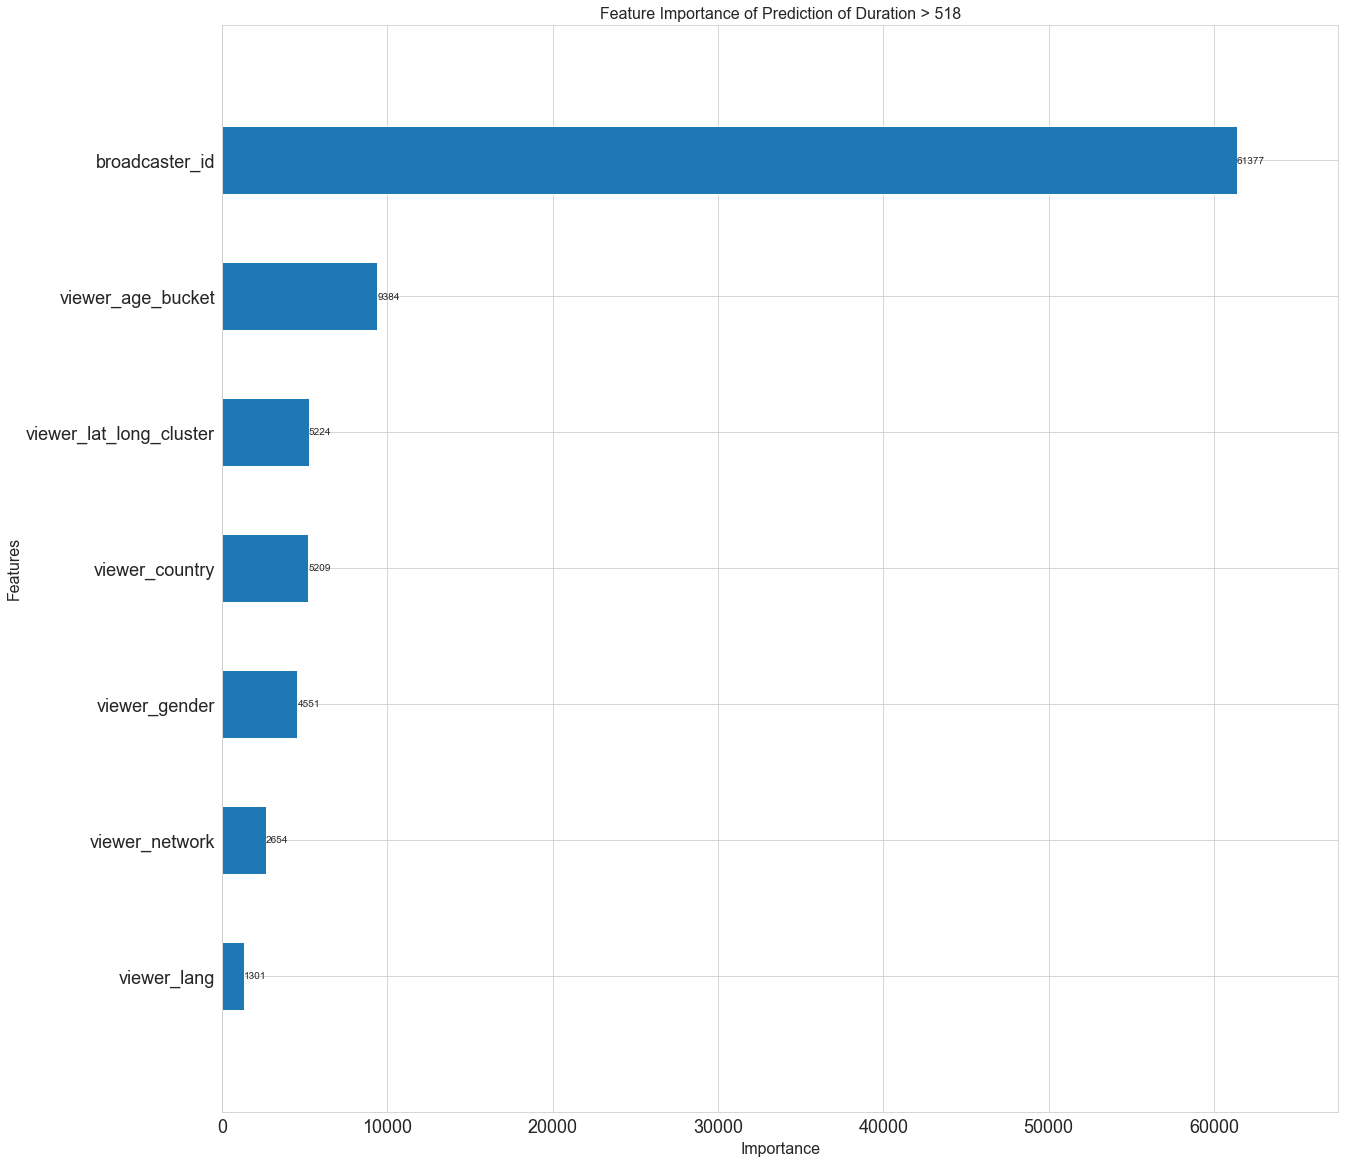

In [41]:
lgb.plot_importance(pred_model, figsize=(20,20), height=0.5)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)
plt.title("Feature Importance of Prediction of Duration > 518", fontsize=16)
plt.xlabel("Importance", fontsize=16)
plt.ylabel("Features", fontsize=16)
plt.show()

In [42]:
boost = pred_model.booster_

In [43]:
imps = pd.DataFrame({'feature': boost.feature_name(),
                    'importance': boost.feature_importance()})

In [44]:
imps.sort_values('importance',ascending=False)

,feature,importance
0,broadcaster_id,61377
2,viewer_age_bucket,9384
6,viewer_lat_long_cluster,5224
5,viewer_country,5209
3,viewer_gender,4551
1,viewer_network,2654
4,viewer_lang,1301


In [45]:
test_df['y_pred_class'] = test_df['y_pred'].apply(lambda x: 1 if x >= 0.5 else 0)

In [46]:
print(classification_report(test_df['y'], test_df['y_pred_class']))

              precision    recall  f1-score   support

           0       0.88      1.00      0.93   2110004
           1       0.46      0.01      0.01    298022

    accuracy                           0.88   2408026
   macro avg       0.67      0.50      0.47   2408026
weighted avg       0.83      0.88      0.82   2408026



### Export models

In [47]:
import traceback
import os
import shutil
import json
import zipfile
from datetime import datetime

In [48]:
def safe_delete_folder(path):
    if os.path.exists(path):
        shutil.rmtree(path)

In [49]:
def init_folder(path):
    if not os.path.exists(path):
        os.makedirs(path)

In [50]:
class SavingModelException(RuntimeError):
    pass

In [51]:
def serialize_model_params(model_params: dict, file_path: str, format_: str="json"):
    if format_ == "edn":
        with open(file_path, "w", encoding='utf8') as text_file:
            text_file.write(edn.dumps(model_params))
    elif format_ == "pickle":
        with open(file_path, "wb") as obj_file:
            pickle.dump(model_params, obj_file, protocol=pickle.HIGHEST_PROTOCOL)
    elif format_ == "json":
        with open(file_path, "w") as obj_file:
            json.dump(model_params, obj_file)
    else:
        raise SavingModelException("model serialization data format {} not supported".format(format_))


def deserialize_model_params(file_path: str, format_: str="json"):
    if format_ == "edn":
        with open(file_path, 'r', encoding="utf-8") as text_file:
            return dict(edn.loads(text_file.read()))
    elif format_ == "pickle":
        with open(file_path, 'rb') as obj_file:
            return pickle.load(obj_file)
    elif format_ == "json":
        with open(file_path, "r") as obj_file:
            return json.load(obj_file)
    else:
        raise SavingModelException("model deserialization data format {} not supported".format(format_))

In [52]:
def save_to_local_zip_file(model_name, model, params):
    ''' Save three files into local folder and zip the folder as a zipped file
        read_me.json tells predict model name, type, and model file, and hyper-params file
        model_xxx.txt is the lightgbm model
        optimus_hyper_params_xxx.json includes all parameters
     '''
    try:
        # Step 1: clean the previous folder if existing
        local_folder = f"./local_{model_name}"
        local_zip_model_path = f"./local_{model_name}.zip"
        safe_delete_folder(local_folder)
        init_folder(local_folder)

        # Step 2: save model and hyper parameters into target zip file
        local_model_path = f"{local_folder}/ranking_model_{model_name}.txt"
        model.save_model(local_model_path)

        local_feature_path = f"{local_folder}/ranking_hyper_params_{model_name}.json"
        serialize_model_params(model_params=params, file_path=local_feature_path)

        read_me_param = {
            'model_name': model_name,
            'model_type': 'lightgbm',
            'model_file': f"ranking_model_{model_name}.txt",
            'hyper_parameter_file': f"ranking_hyper_params_{model_name}.json",
            'date_time': params['update_time']
        }
        local_readme_path = f"{local_folder}/readme.json"
        serialize_model_params(model_params=read_me_param, file_path=local_readme_path)

        with zipfile.ZipFile(local_zip_model_path, 'w', zipfile.ZIP_DEFLATED) as zip:
            for root, dirs, files in os.walk(local_folder):
                for file in files:
                    zip.write(os.path.join(root, file), file)
        return local_zip_model_path
    except Exception:
        print(traceback.format_exc())
        return None

In [53]:
runtime = datetime.now()
pred_metadata['update_time'] = runtime.strftime("%Y_%m_%d_%H_%M_%S")
pred_metadata['update_time']

'2021_11_18_13_43_11'

In [54]:
save_to_local_zip_file("cold_start_lightgbm_cutoff518", pred_model.booster_, pred_metadata)

'./local_cold_start_lightgbm_cutoff518.zip'

### Scoring and profiling the dataset

In [55]:
df_score = df.copy()

In [56]:
from tempfile import TemporaryDirectory
def extract_lightgbm_model_params(file_path: str, model_name: str):
    with zipfile.ZipFile(file_path, 'r') as zf:
        with TemporaryDirectory() as tf:
            hyper_file = zf.extract(f'ranking_hyper_params_{model_name}.json', tf)
            model_file = zf.extract(f'ranking_model_{model_name}.txt', tf)
            with open(hyper_file, 'r') as f:
                hyper_param = json.load(f)
            return {"params": hyper_param,
                    "model": lgb.Booster(model_file=model_file)}

In [57]:
model_name = "cold_start_lightgbm_cutoff518"
local_model_file = f"./local_{model_name}.zip"
model = extract_lightgbm_model_params(local_model_file, model_name)

In [58]:
for f in FEATURES:
    df_score[f] = df_score[f].astype('category')

In [60]:
model['params']['features']

['broadcaster_id',
 'viewer_network',
 'viewer_age_bucket',
 'viewer_gender',
 'viewer_lang',
 'viewer_country',
 'viewer_lat_long_cluster']

In [61]:
df_score.loc[:, 'prediction'] = model['model'].predict(df_score[model['params']['features']])

In [62]:
df_score.to_csv("df_score_518.csv", index = False)